# GradCAM Analysis

In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
import os 
import sys
import glob 
import numpy as np
import matplotlib.pyplot as plt

from plotting import load_tensor_from_tiff, make_composite, plot_gradcam_counterfactual, plot_relative_gradcam_activation, plot_gradcam

dir2 = os.path.abspath('')
dir1 = os.path.dirname(dir2)
if not dir1 in sys.path: sys.path.append(dir1)
    
from models import AvgPoolCNN
from data import get_test_transforms

In [10]:
IM_DIR = '../../DATA/E_coli_images'
device = 'cpu'

In [11]:
model = AvgPoolCNN.from_pretrained(
            species='Ecoli',                       
            channels=['BF'],                       
            replicate=2,                           
        )

model.to(device)
model.eval()

AvgPoolCNN(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale_activation): 

# Saliency maps

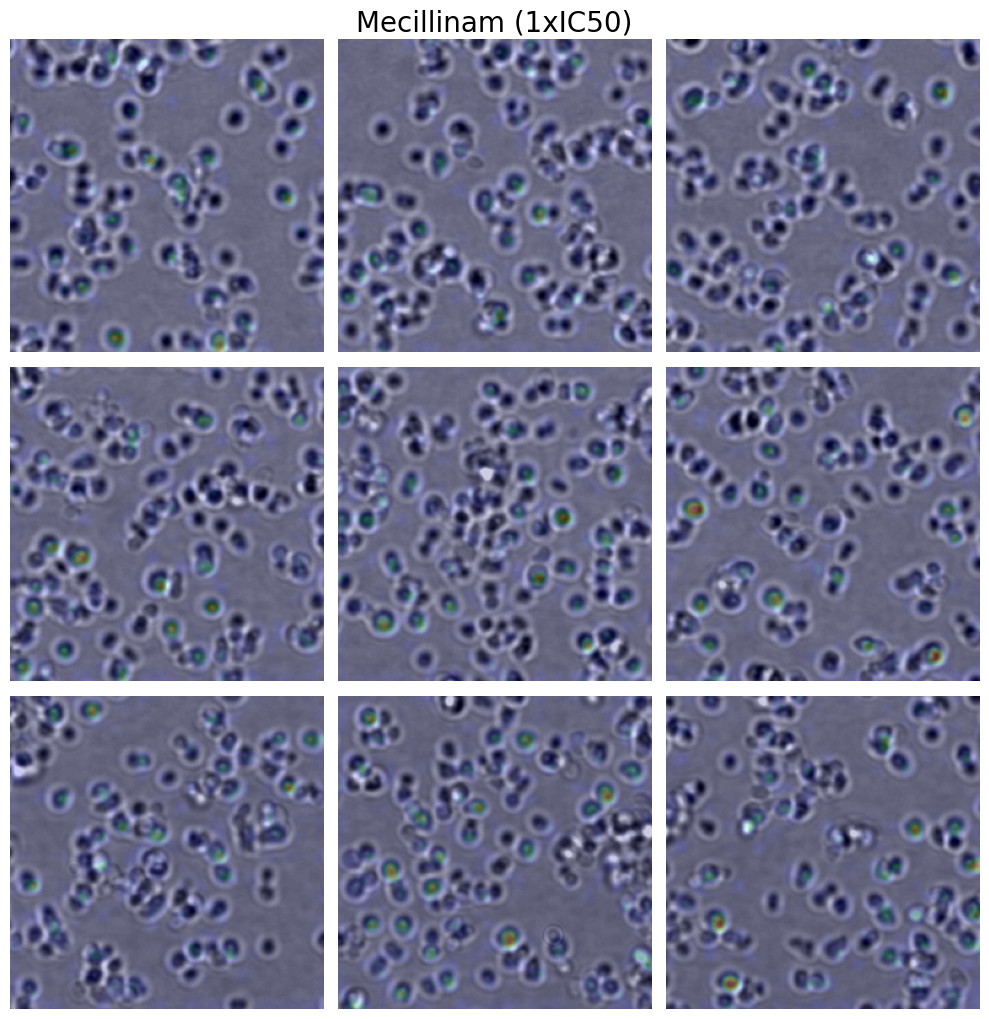

In [12]:
cmpd_name = 'Mecillinam_1xIC50'
img = load_tensor_from_tiff(os.path.join(IM_DIR, f'{cmpd_name}_BF.tiff'))

input_tensor = get_test_transforms()(img.unsqueeze(0)).unsqueeze(0).to(device)

plot_gradcam(model, input_tensor, cmpd_name)

# Counterfactual saliency maps and quantification of relative activation

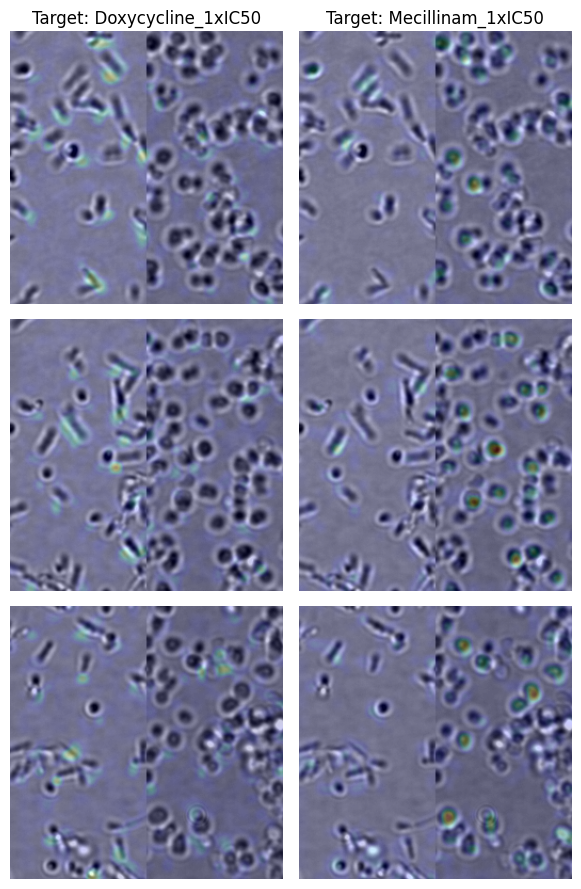

In [13]:
cmpd_name_1 = 'Doxycycline_1xIC50'
cmpd_name_2 = 'Mecillinam_1xIC50'

img_1 = load_tensor_from_tiff(os.path.join(IM_DIR, f'{cmpd_name_1}_BF.tiff'))
img_2 = load_tensor_from_tiff(os.path.join(IM_DIR, f'{cmpd_name_2}_BF.tiff'))

img_c = make_composite(img_1, img_2).unsqueeze(0)
input_tensor = get_test_transforms()(img_c).unsqueeze(0).to(device)

plot_gradcam_counterfactual(model, input_tensor)

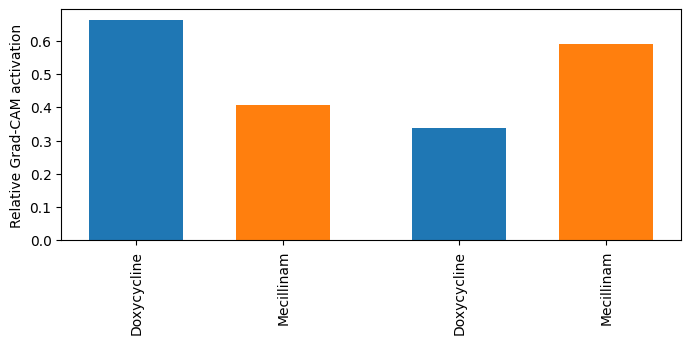

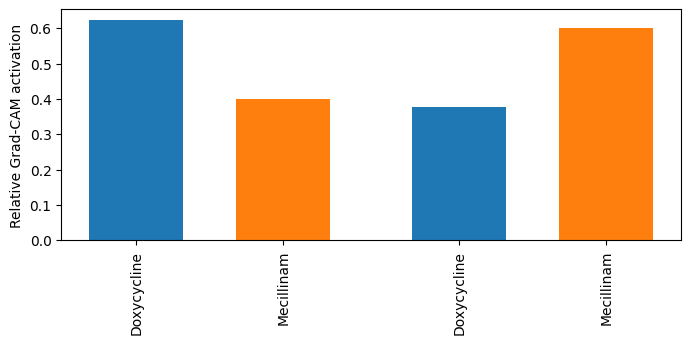

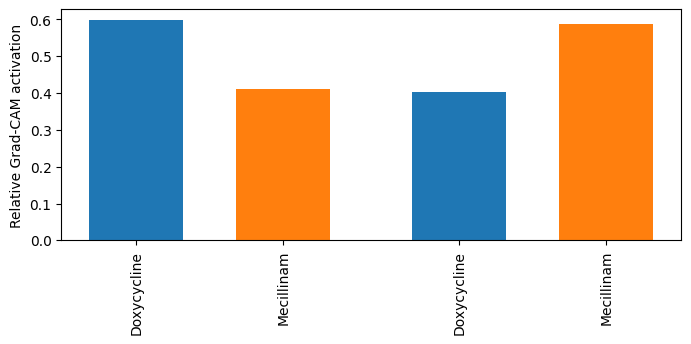

In [14]:
plot_relative_gradcam_activation(model, input_tensor)